# HERVIOU-LABORDE Colin
# NGUYEN Minh-Quân

# TP noté -- Statistical models for decision making - partie 2

Cet devoir noté est composé de deux exercices. Il sera idéalement réalisé en binome et éventuellement seul. Les réponses seront données dans un notebook qui indiquera clairement les **noms et prénoms des élèves** l'ayant realisé.


## Exercice 1

Nous souhaitons évaluer si un nouveau produit a un effet significatif sur le rendement de moteurs. Pour y répondre, ce rendement (*Efficiency*) a été mesuré sur deux types de moteurs (*Brand_1* et *Brand_2*) et en testant différents niveaux de concentration (*Concentration*) du produit. Les observations sont dans le fichier *E2_Efficiency_Obs.csv*. Plus spécifiquement, nous nous demandons :
- Le produit semble-t-il avoir un effet ?
- Cet effet est-il différent en fonction de la marque du moteur ?
- Cet effet dépend-il de la concentration du produit ?

### Question 1.1 

Ouvrez et observez les données. A leur vue, quelle vous semble être la réponse aux trois questions posées plus haut ?

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataframe=pd.read_csv("./E1_Efficiency_Obs.csv",sep=',')

FileNotFoundError: [Errno 2] No such file or directory: './E1_Efficiency_Obs.csv'

In [29]:
dataframe.head()


,Brand,Concentration,Efficiency
0,Brand_1,3.9479,3.2224
1,Brand_1,1.7838,1.5127
2,Brand_1,7.4415,4.3736
3,Brand_1,8.5625,5.2151
4,Brand_1,9.8002,5.4256


On trace un nuage de points représentant l'efficacité du produit par rapport a sa concentration en utilisant des couleurs distinctes en fonction de lu type de moteur

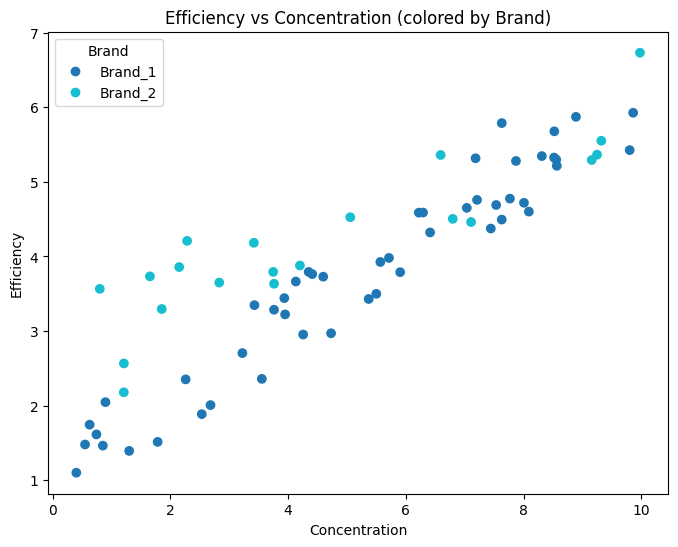

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    dataframe["Concentration"],
    dataframe["Efficiency"],
    c=pd.factorize(dataframe["Brand"])[0],  # convert brands to numbers
    cmap="tab10",                           # color palette
)

plt.xlabel("Concentration")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Concentration (colored by Brand)")

# add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, dataframe["Brand"].unique(), title="Brand")

plt.show()

Comme le montre le nuage de points ci-dessus il semble y avoir une relation linéaire positive entre la concentration du produit et l'efficacité du moteur.
Au premier abord:
- Le produit semble avoir un effet positif sur l'efficacité du moteur: plus on met de produit, plus l'efficacité est améliorée.
- Cet effet serait meilleur pour le type Brand_2 que le type Brand_1, en effet, pour une même concentration, l'efficacité sur le type de moteur Brand_2 semble légèrement supérieure à celle sur le type de moteur Brand_1.
- Il y a vraisemblablement une relation linéraire positive entre la concentration du produit et l'efficacité du moteur. Cette dernière augmenterait proportionnellement avec la concentration du produit.

### Question 1.2 

Afin de répondre aux questions, deux hypothèses sont formulées :
- Pour chaque marque de moteur, la relation entre la concentration et le rendement est supposée linéaire.
- La distribution du bruit des observations est supposé suivre une loi Normale centrée.

Quelle démarche de modélisation statistique allez-vous utiliser pour répondre aux trois questions posées en introduction ? Une fois la démarche bien expliquée, testez la sur les données observées afin de conclure sur l'efficacité du produit.

Démarche:

On réalise une analyse de covariance (ANCOVA) afin de tester à la fois l'effet du produit et du type de moteur sur leur efficacité.

On compare un modèle linéaire complet (une régression simple par groupe). En choisissant un groupe de référence, disons le type de moteur 1. On teste ensuite les hypothèses suivantes:

- H0 : les pentes sont égales (teste la différence d'effet du produit en fonction du type de moteur)
- H0 : les intercepts sont égaux (teste l'efficacité de base des moteurs, sans produit)
- H0 : les pentes sont nulles (teste l'effet du produit)

Pour faire cela, on compare le modèle complet aux modèles réduits correspondant à ces hypothèses. Un test de fisher test l'égalité entre les variances des résidus des différents modèles.

### Modèle complet

In [ ]:
from sklearn.linear_model import LinearRegression

X = dataframe['Concentration'].values.reshape(-1, 1)
y = dataframe['Efficiency']


X = dataframe[dataframe['Brand'] == 'Brand_1']['Concentration'].values.reshape(-1, 1)
y = dataframe[dataframe['Brand'] == 'Brand_1']['Efficiency']

lr1 = LinearRegression()
lr1.fit(X, y)

y_pred_1 = lr1.predict(X)


X = dataframe[dataframe['Brand'] == 'Brand_2']['Concentration'].values.reshape(-1, 1)
y = dataframe[dataframe['Brand'] == 'Brand_2']['Efficiency']

lr2 = LinearRegression()
lr2.fit(X, y)

y_pred_2 = lr2.predict(X)

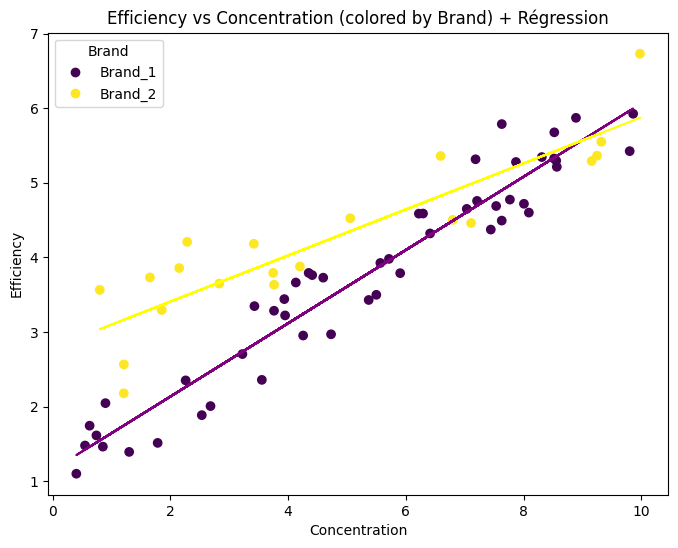

In [53]:
# Scatter plot des points
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    dataframe["Concentration"],
    dataframe["Efficiency"],
    c=pd.factorize(dataframe["Brand"])[0],  # convert brands to numbers
)

# add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, dataframe["Brand"].unique(), title="Brand")

# Ajouter la droite de régression
# plt.plot(dataframe['Concentration'], y_pred_tot, color='red', label='Régression linéaire (tous les points)')
plt.plot(dataframe[dataframe['Brand'] == 'Brand_1']['Concentration'], y_pred_1, color='purple')
plt.plot(dataframe[dataframe['Brand'] == 'Brand_2']['Concentration'], y_pred_2, color='yellow')

plt.xlabel("Concentration")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Concentration (colored by Brand) + Régression")
plt.show()


### (i) H0: les pentes sont égales

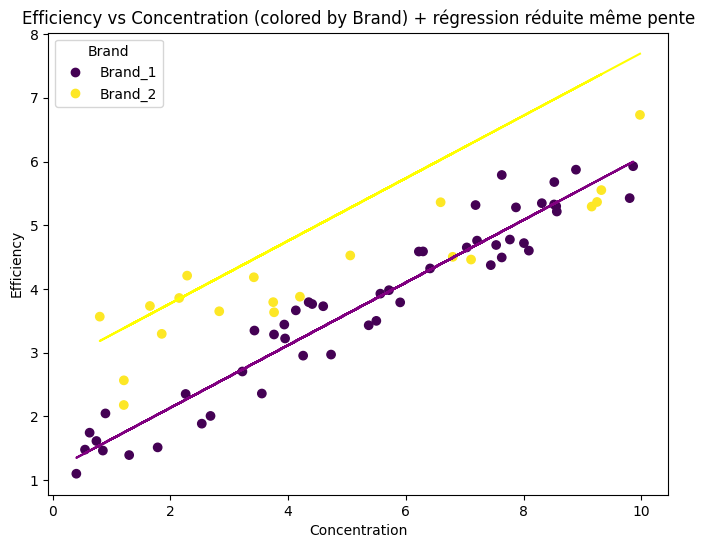

In [52]:
X = dataframe[dataframe['Brand'] == 'Brand_2']['Concentration'].values.reshape(-1, 1)

y_pred_2i = lr1.coef_[0] * X + lr2.intercept_

# Scatter plot des points
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    dataframe["Concentration"],
    dataframe["Efficiency"],
    c=pd.factorize(dataframe["Brand"])[0],  # convert brands to numbers
)

# add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, dataframe["Brand"].unique(), title="Brand")

# Ajouter la droite de régression
# plt.plot(dataframe['Concentration'], y_pred_tot, color='red', label='Régression linéaire (tous les points)')
plt.plot(dataframe[dataframe['Brand'] == 'Brand_1']['Concentration'], y_pred_1, color='purple')
plt.plot(dataframe[dataframe['Brand'] == 'Brand_2']['Concentration'], y_pred_2i, color='yellow')

plt.xlabel("Concentration")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Concentration (colored by Brand) + régression réduite même pente")
plt.show()

### (ii) H0: les intercepts sont égaux

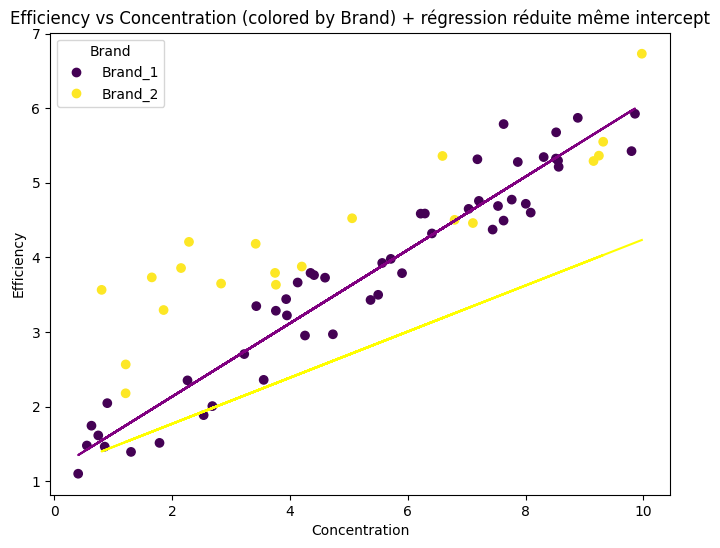

In [51]:
X = dataframe[dataframe['Brand'] == 'Brand_2']['Concentration'].values.reshape(-1, 1)

y_pred_2ii = lr2.coef_[0] * X + lr1.intercept_

# Scatter plot des points
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    dataframe["Concentration"],
    dataframe["Efficiency"],
    c=pd.factorize(dataframe["Brand"])[0],  # convert brands to numbers
)

# add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, dataframe["Brand"].unique(), title="Brand")

# Ajouter la droite de régression
# plt.plot(dataframe['Concentration'], y_pred_tot, color='red', label='Régression linéaire (tous les points)')
plt.plot(dataframe[dataframe['Brand'] == 'Brand_1']['Concentration'], y_pred_1, color='purple')
plt.plot(dataframe[dataframe['Brand'] == 'Brand_2']['Concentration'], y_pred_2ii, color='yellow')

plt.xlabel('Concentration')
plt.ylabel('Efficiency')
plt.title("Efficiency vs Concentration (colored by Brand) + régression réduite même intercept")
plt.show()

### (iii) H0: les pentes sont nulles

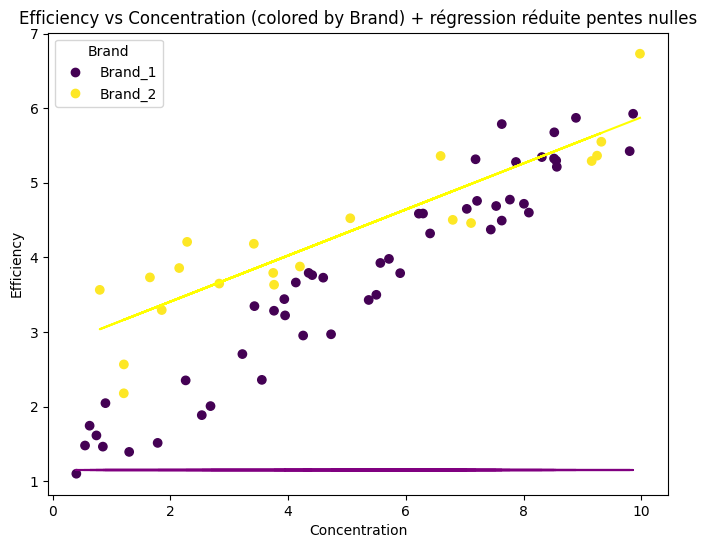

In [54]:
X = dataframe[dataframe['Brand'] == 'Brand_1']['Concentration'].values.reshape(-1, 1)

y_pred_1iii = 0 * X + lr1.intercept_

# Scatter plot des points
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    dataframe["Concentration"],
    dataframe["Efficiency"],
    c=pd.factorize(dataframe["Brand"])[0],  # convert brands to numbers
)

# add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, dataframe["Brand"].unique(), title="Brand")

# Ajouter la droite de régression
# plt.plot(dataframe['Concentration'], y_pred_tot, color='red', label='Régression linéaire (tous les points)')
plt.plot(dataframe[dataframe['Brand'] == 'Brand_1']['Concentration'], y_pred_1iii, color='purple')
plt.plot(dataframe[dataframe['Brand'] == 'Brand_2']['Concentration'], y_pred_2, color='yellow')

plt.xlabel("Concentration")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Concentration (colored by Brand) + régression réduite pentes nulles")
plt.show()

## Exercice 2


Afin d'estimer efficacement le niveau de fatigue des ailes d'un d'avion au cours des années, il a été proposé de lancer une étude pour évaluer s'il était possible de déduire le niveau de stress subit par les ailes de l'avion lors de phases de vols diverses avec de données capteurs acquises en routine pendant les vols. Une personne ayant une expertise mécanique sur le modèle d'avion étudié a alors quantifié le niveau de stress subi par les ailes dans différentes phases de vols et différents contextes. Nous allons mettre en lien ces niveaux de stress avec des données capteurs acquises au même moment que les annotations. Nous allons pour cela utiliser la régression linaire. 


### QUESTION 2.1

Les données d'apprentissage sont dans les fichiers *E2_sensor_vals.csv* et *E2_stress_vals.csv*. Ouvrez ces fichiers et mettez les données dans des numpy arrays ou des pandas dataframes *X* et *Y*. Représentez alors le lien entre les valeurs issues de chaque capteur et le niveau de stress dans des nuages de points 2D. Identifiez-vous des relations entre des données capteur et le niveau de stress ? Quels capteurs vous paraissent être les plus pertinents.
 

In [62]:
import os

os.getcwd()

FileNotFoundError: [Errno 2] No such file or directory

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing


X = pd.read_csv('E2_sensor_vals.csv', delimiter=';')

Y = pd.read_csv('E2_stress_vals.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'E2_sensor_vals.csv'

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

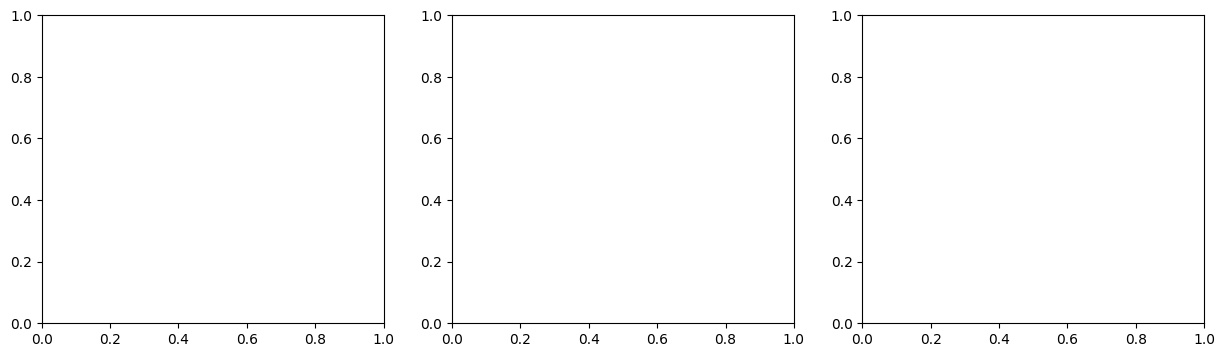

In [56]:
# S'assurer que Y est un vecteur 1D (au cas où il ait une seule colonne)
if Y.shape[1] == 1:
    y = Y.iloc[:, 0]
else:
    raise ValueError("Y contient plus d'une colonne, préciser laquelle utiliser.")

# Nombre de variables dans X
n_features = X.shape[1]

# Définir le nombre de lignes/colonnes pour les subplots
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

# Création des subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # Pour indexer facilement

for i, col in enumerate(X.columns):
    axes[i].scatter(X[col], y, alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Y")
    axes[i].set_title(f"Y vs {col}")

# Supprimer les axes inutilisés si le nombre de subplots est supérieur au nombre de colonnes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

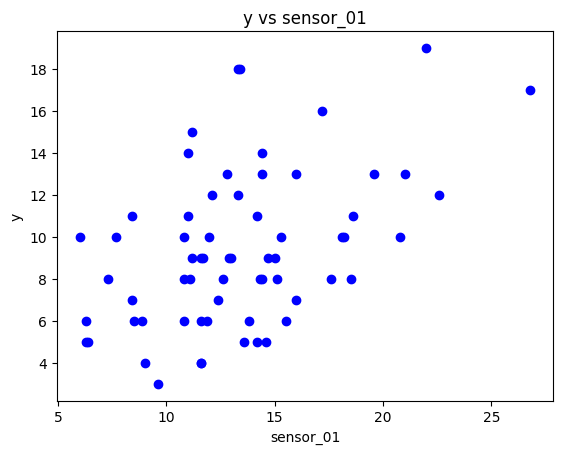

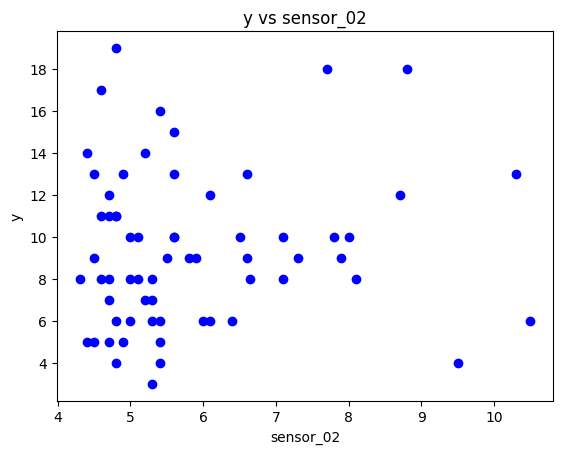

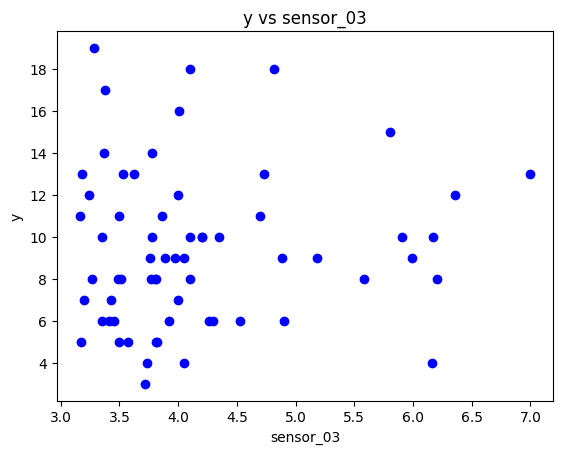

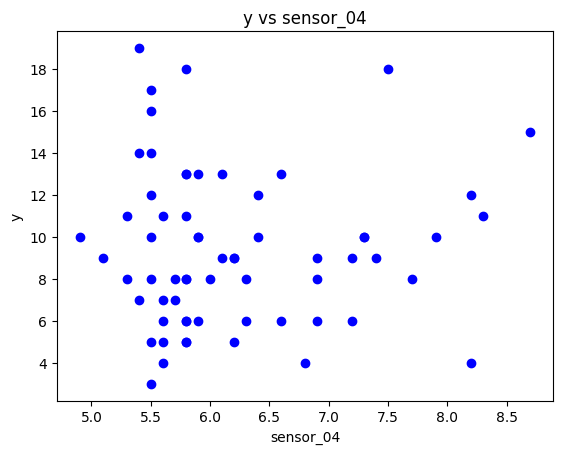

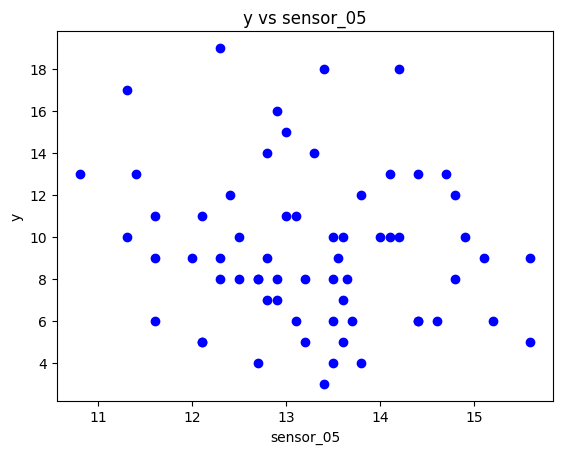

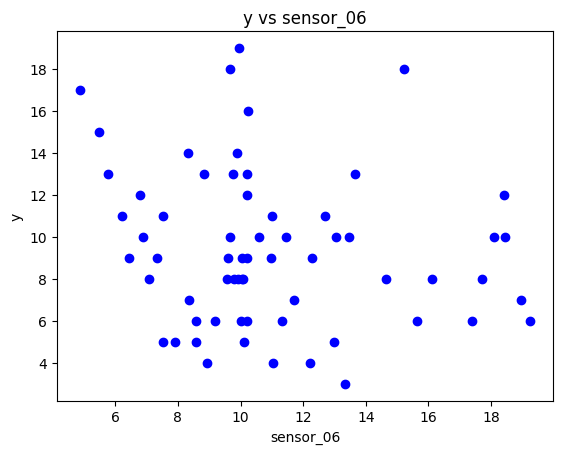

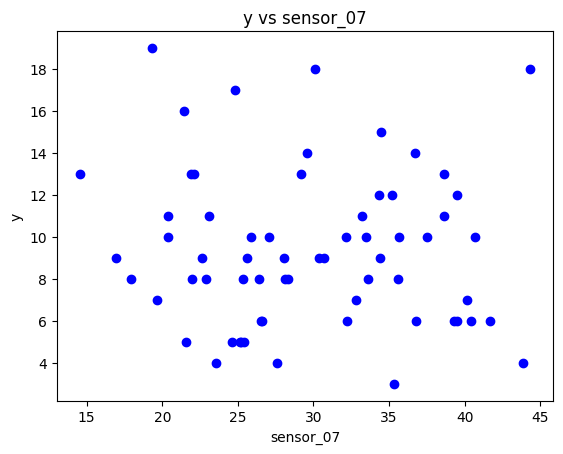

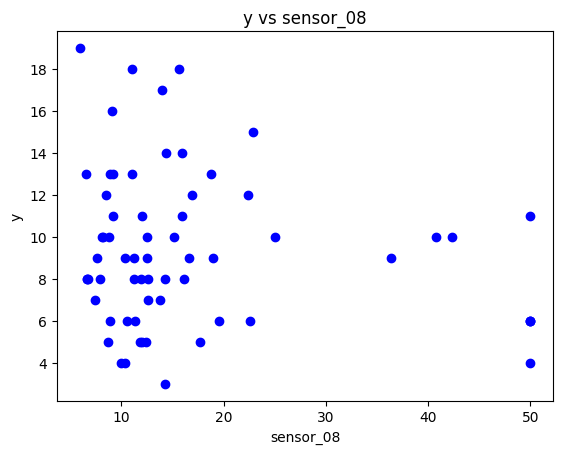

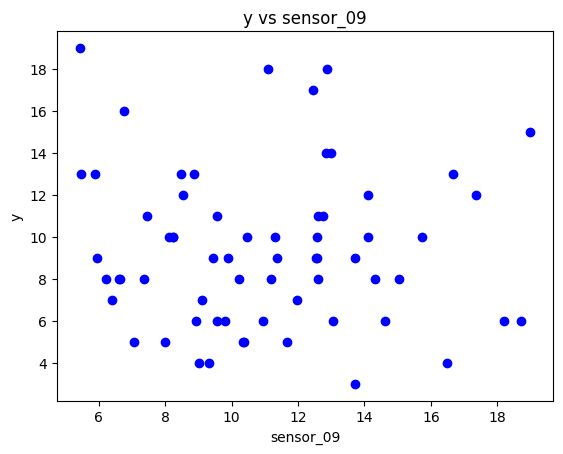

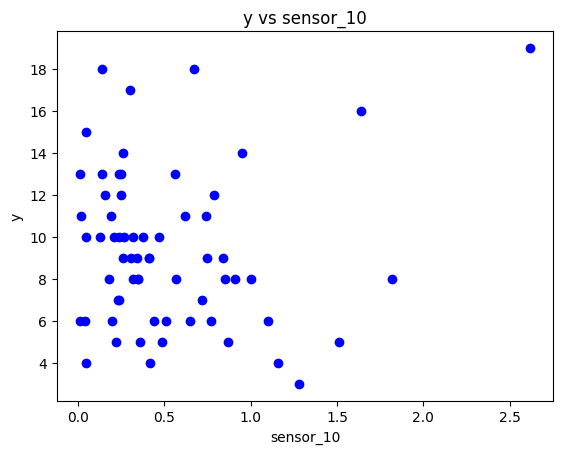

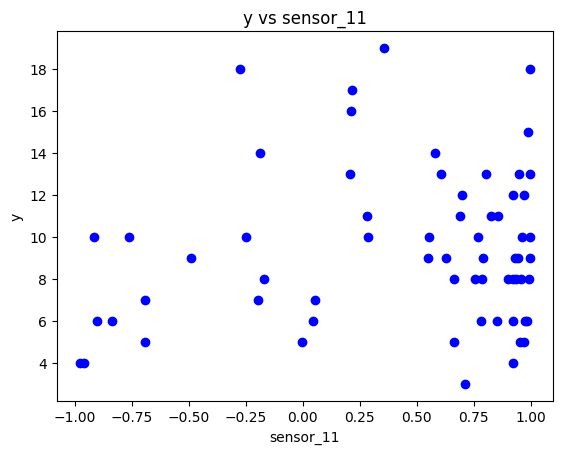

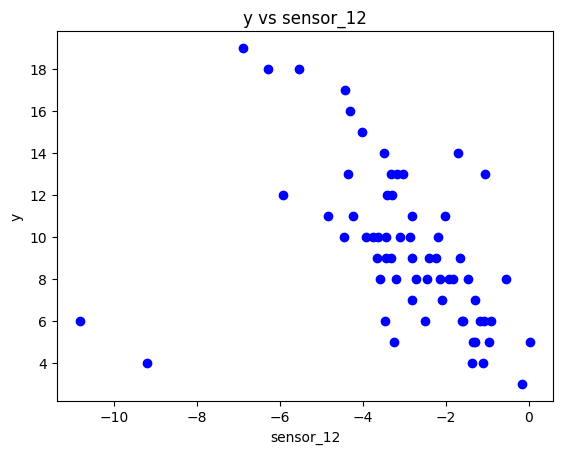

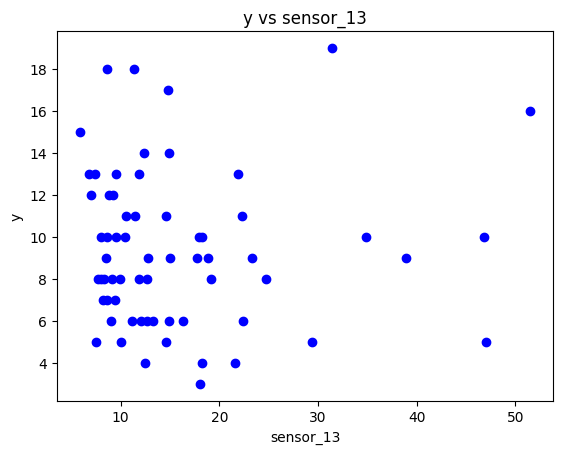

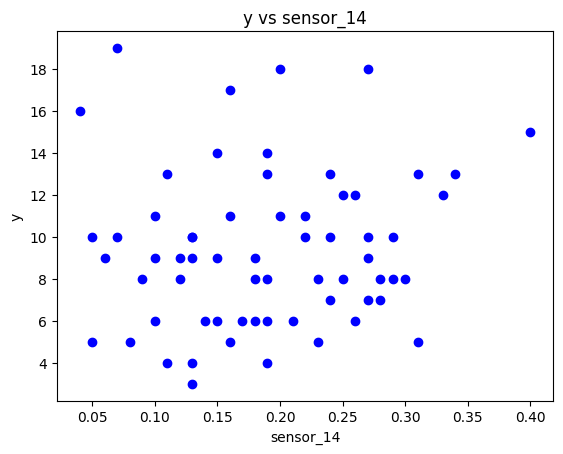

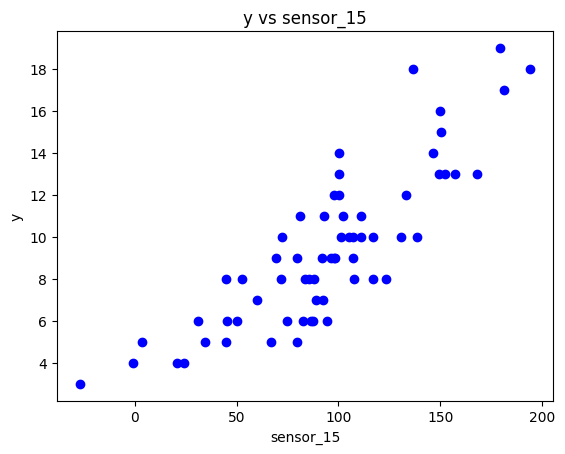

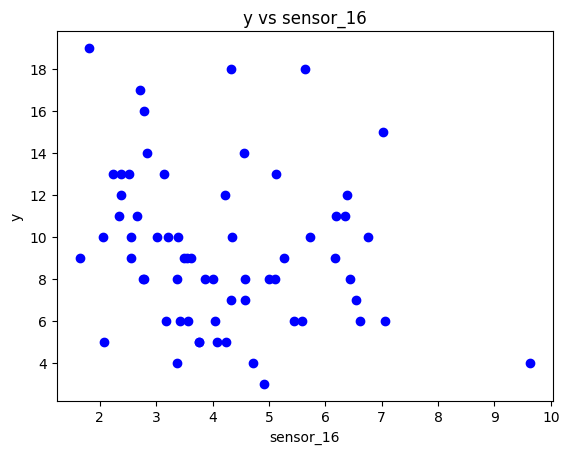

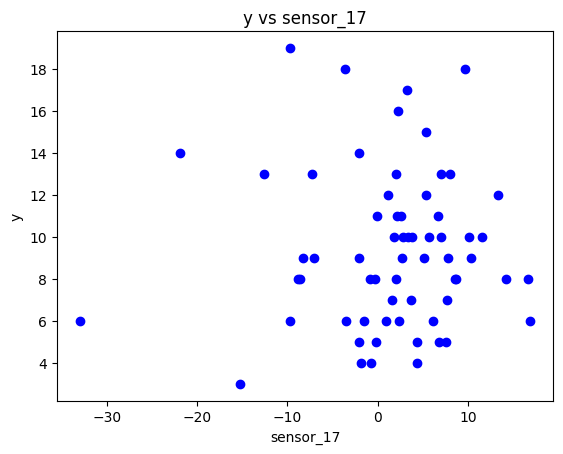

In [42]:
for col in X.columns:
    plt.figure()
    plt.scatter(X[col], Y, color='blue')
    plt.xlabel(col)
    plt.ylabel('y')
    plt.title(f'y vs {col}')
    plt.show()


### QUESTION 2.2
On se demande s'il est possible de prédire le niveau de stress à partir d'**une seule** des variables *sensor_01*, *sensor_12* ou *sensor_15*.


#### QUESTION 2.2.1

Effectuez une régression linéaire simple entre chacune de ces trois variables et le niveau de stress. Quelle stratégie de validation croisée vous semble être la plus adaptée sur ce jeu de données ?


#### QUESTION 2.2.2

Peut-on statistiquement affirmer qu'il existe une relation significative entre le niveau de stress et (indépendament) *sensor_01*, *sensor_12* ou bien *sensor_15* ? Si oui, décrivez votre procédure de test.



### QUESTION 2.3

On s'intéresse maintenant au lien entre la variable *sensor_12* et le niveau de stress. On peut remarquer qu'il semble exister une relation linéaire entre ces variables, mais que les données contiennent aussi deux valeurs aberrantes.


#### QUESTION 2.3.1

**Stratégie 1** : Quelle stratégie utiliseriez vous pour détecter automatiquement des données aberrantes dans un jeu de données ?

#### QUESTION 2.3.2

**Stratégie 2** : Nous allons ici utiliser toutes les observations pour l'apprentissage du modèle linéaire et sa validation. En supposant que les erreurs de prédiction suivent une loi normale centrée, pourrait-on aussi détecter les outliers à partir d'un test d'hypothèse. Si oui, décrivez la procédure.



### QUESTION 2.4


Nous supprimerons dans cette question les deux observations qui sont aberrantes sur la variable *sensor_12*.

Nous souhaitons maintenant sélectionner automatiquement un nombre réduit, mais supérieur à 1, de capteurs qui nous permettraient de prédire au mieux le niveau de stress. Nous allons pour cela utiliser la régression multiple avec un terme de régularisation.

#### QUESTION 2.4.1

Avant d'effectuer une régression linéaire régularisée, il est vivement conseillé d'effectuer une étape de centrage réduction des données. Pourquoi ?


#### QUESTION 2.4.2

Décrivez votre démarche de sélection de variables et vos résultats. Est-ce que l'utilisation des données capteurs vous semble fiable ? 


#### QUESTION 2.4.3

Quelle démarche auriez-vous pour rendre compte des résultats de cette étude sachant que les données contenaient tout de même deux outliers ?

